# Residual GAN Augmentation (Raw Waveform) – Excavation Only
Bu notebook **sequences.py'ye dokunmadan** excavation class'ı için **residual GAN** eğitir ve augmentation çıktısını görselleştirir.

**Önemli:** Bu süreç raw waveform ile çalışır ama GAN eğitiminde *residual normalizasyonu* kullanır (normalize → GAN → denormalize). Aksi halde GAN residual RMS'i 1 civarına çakılır (senin yaşadığın durum).

In [2]:
# CELL 0 — Imports & Matplotlib
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf


2025-12-16 08:43:19.066200: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-16 08:43:19.066291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-16 08:43:19.094463: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-16 08:43:19.158444: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# CELL 1 — Pipeline imports (sequences tarafı değişmiyor)
# Not: Bu importlar senin mevcut repo dosyalarına dayanır.
from sequences import _load_sequence_dataframe, _load_signal_from_row
from config import load_class_info


In [4]:
# CELL 2 — Ayarlar (burayı değiştirmen yeter)
DATA_FOLDER = Path("/tf/start_training/data/signal/2025-11-27_5clf_best_data")
WINDOW_SIZE = 20000
LABEL = "excavation"

LATENT_CH = 8            # z'nin zaman eksenindeki kanal sayısı
LR = 2e-4
BATCH = 8
STEPS = 3000             # 1–3k başlangıç için yeter

# Loss ağırlıkları
LAMBDA_FFT = 1.0
LAMBDA_RMS = 2.0         # enerji çökmesini engeller
LAMBDA_REG = 1e-6

# Augmentation şiddeti (inference/plot için)
TARGET_RMS_RATIO = 0.10  # residual RMS, real RMS'in %10'u gibi
RNG_SEED = 42
np.random.seed(RNG_SEED)
tf.random.set_seed(RNG_SEED)


In [5]:
# CELL 3 — CSV ve excavation filtre
df = _load_sequence_dataframe(DATA_FOLDER / "train.csv")
class_info = load_class_info(DATA_FOLDER)
classes = class_info.classes

exc_df = df[df["event"] == LABEL].reset_index(drop=True)

print("Classes:", classes)
print("Train samples:", len(df))
print("Excavation samples:", len(exc_df))
assert len(exc_df) >= 2*BATCH, "Excavation verisi çok az. BATCH düşür veya daha fazla veri kullan."


Classes: ['car', 'digging', 'excavation', 'noise', 'walking']
Train samples: 74792
Excavation samples: 16223


In [6]:
# CELL 4 — Batch loader (x1, x2) (excavation içinden iki ayrı örnek)
def get_excavation_batch(df_exc, batch):
    idx = np.random.choice(len(df_exc), batch * 2, replace=False)
    xs = []
    for i in idx:
        row = df_exc.iloc[i]
        x = _load_signal_from_row(row, WINDOW_SIZE).astype(np.float32)
        xs.append(x)
    xs = np.stack(xs)  # (2B, T)
    x1 = xs[:batch]
    x2 = xs[batch:]
    return (
        tf.convert_to_tensor(x1[:, :, None]),  # (B,T,1)
        tf.convert_to_tensor(x2[:, :, None]),  # (B,T,1)
    )

# hızlı sanity
x1, x2 = get_excavation_batch(exc_df, BATCH)
print(x1.shape, x2.shape)


2025-12-16 08:43:24.081287: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-16 08:43:24.121581: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-16 08:43:24.123193: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

(8, 20000, 1) (8, 20000, 1)


2025-12-16 08:43:24.125897: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-16 08:43:24.127506: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-16 08:43:24.129061: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [7]:
# CELL 5 — Residual normalization helpers (sample-wise)
# r_real: (B,T,1)
def normalize_residual(r):
    # r: (B,T,1)
    mean = tf.reduce_mean(r, axis=1, keepdims=True)
    std  = tf.math.reduce_std(r, axis=1, keepdims=True) + 1e-6
    r_n = (r - mean) / std
    return r_n, mean, std


def denormalize_residual(r_norm, mean, std):
    return r_norm * std + mean

def rms_tf(x):
    return tf.sqrt(tf.reduce_mean(tf.square(x), axis=[1,2]) + 1e-12)      # (B,)


In [8]:
# CELL 6 — Losses
def fft_logmag_loss(r_gan_norm, r_real_norm):
    # r_*: (B,T,1)
    rg = tf.squeeze(r_gan_norm, -1)   # (B,T)
    rr = tf.squeeze(r_real_norm, -1)  # (B,T)

    Mg = tf.math.log1p(tf.abs(tf.signal.rfft(rg)))
    Mr = tf.math.log1p(tf.abs(tf.signal.rfft(rr)))

    return tf.reduce_mean(tf.abs(Mg - Mr))

def rms_ratio_loss(r_gan_norm, r_real_norm):
    # log RMS ratio distance (stabil)
    rg = rms_tf(r_gan_norm)
    rr = rms_tf(r_real_norm)
    return tf.reduce_mean(tf.abs(tf.math.log(rg + 1e-12) - tf.math.log(rr + 1e-12)))


def envelope(x, win=128):
    # abs + moving average
    x = tf.abs(x)
    k = tf.ones((win,1,1), dtype=x.dtype) / float(win)
    return tf.nn.conv1d(x, k, stride=1, padding="SAME")

def env_loss(r_gan_n, r_real_n):
    eg = envelope(r_gan_n)
    er = envelope(r_real_n)
    return tf.reduce_mean(tf.abs(eg - er))



In [9]:
# CELL 7 — Generator (time-wise z) — sequences tarafına dokunmadan
# Input: x_real (B,T,1), z (B,T,LATENT_CH)
# Output: r_gan_norm (B,T,1)  (normalize edilmiş residual)
from tensorflow.keras import layers, Model

def build_residual_generator(T, z_ch=8, base=64):
    x_real = layers.Input(shape=(T,1), name="x_real")
    z = layers.Input(shape=(T,z_ch), name="z_time")

    x = layers.Concatenate(name="concat_real_z")([x_real, z])

    # Hafif ama yeterli bir conv stack
    x = layers.Conv1D(base, 25, padding="same")(x);  x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv1D(base*2, 25, padding="same")(x);x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv1D(base*2, 25, padding="same")(x);x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv1D(base, 25, padding="same")(x);  x = layers.LeakyReLU(0.2)(x)

    # Çıkış LINEAR (tanh yok) — normalize residual üretileceği için güvenli
    r = layers.Conv1D(1, 25, padding="same", activation=None, name="r_norm")(x)
    return Model([x_real, z], r, name="residual_generator_norm")

GEN = build_residual_generator(WINDOW_SIZE, z_ch=LATENT_CH, base=64)
GEN.summary()


Model: "residual_generator_norm"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 x_real (InputLayer)         [(None, 20000, 1)]           0         []                            
                                                                                                  
 z_time (InputLayer)         [(None, 20000, 8)]           0         []                            
                                                                                                  
 concat_real_z (Concatenate  (None, 20000, 9)             0         ['x_real[0][0]',              
 )                                                                   'z_time[0][0]']              
                                                                                                  
 conv1d (Conv1D)             (None, 20000, 64)            14464     ['concat

In [10]:
# CELL 8 — Training loop (excavation-only)
opt = tf.keras.optimizers.Adam(LR)

@tf.function
def train_step(x1, x2):
    r_real = x2 - x1                              # (B,T,1)
    r_real_n, r_mean, r_std = normalize_residual(r_real)

    z = tf.random.normal((tf.shape(x1)[0], WINDOW_SIZE, LATENT_CH))
    with tf.GradientTape() as tape:
        r_gan_n = GEN([x1, z], training=True)

        loss_fft = fft_logmag_loss(r_gan_n, r_real_n)
        loss_rms = rms_ratio_loss(r_gan_n, r_real_n)
        loss_reg = tf.reduce_mean(tf.square(r_gan_n))
        # loss = LAMBDA_FFT*loss_fft + LAMBDA_RMS*loss_rms + LAMBDA_REG*loss_reg
        loss_env = env_loss(r_gan_n, r_real_n)
        loss = LAMBDA_FFT*loss_fft + LAMBDA_RMS*loss_rms + 0.5*loss_env + LAMBDA_REG*loss_reg


    grads = tape.gradient(loss, GEN.trainable_weights)
    opt.apply_gradients(zip(grads, GEN.trainable_weights))


    GEN.trainable = False

    
    # normalize-space RMS'leri raporlamak için
    rg = tf.reduce_mean(rms_tf(r_gan_n))
    rr = tf.reduce_mean(rms_tf(r_real_n))
    return loss, loss_fft, loss_rms, rg, rr

history = {"loss": [], "fft": [], "rms": [], "rg": [], "rr": []}

for step in range(STEPS):
    x1, x2 = get_excavation_batch(exc_df, BATCH)
    loss, lfft, lrms, rg, rr = train_step(x1, x2)

    if step % 100 == 0:
        print(f"[{step}] loss={float(loss):.4f} fft={float(lfft):.4f} rms={float(lrms):.4f} | RMS(n) gan={float(rg):.3f} real={float(rr):.3f}")

    history["loss"].append(float(loss))
    history["fft"].append(float(lfft))
    history["rms"].append(float(lrms))
    history["rg"].append(float(rg))
    history["rr"].append(float(rr))


2025-12-16 08:43:26.659087: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906


[0] loss=12.2626 fft=1.1554 rms=2.5468 | RMS(n) gan=13.134 real=1.000
[100] loss=15.7643 fft=1.1764 rms=2.8149 | RMS(n) gan=19.197 real=1.000
[200] loss=14.1221 fft=1.1849 rms=2.6844 | RMS(n) gan=16.119 real=1.000
[300] loss=13.1650 fft=1.1274 rms=2.5819 | RMS(n) gan=14.778 real=1.000
[400] loss=15.3237 fft=1.2116 rms=2.8643 | RMS(n) gan=17.954 real=1.000
[500] loss=12.2532 fft=1.0178 rms=2.5081 | RMS(n) gan=13.114 real=1.000
[600] loss=15.7292 fft=1.2513 rms=2.7657 | RMS(n) gan=19.097 real=1.000
[700] loss=18.6827 fft=1.3589 rms=3.0754 | RMS(n) gan=23.666 real=1.000
[800] loss=11.4179 fft=1.1470 rms=2.3995 | RMS(n) gan=11.377 real=1.000
[900] loss=13.0525 fft=1.3228 rms=2.5110 | RMS(n) gan=14.681 real=1.000
[1000] loss=12.6784 fft=1.1089 rms=2.5683 | RMS(n) gan=13.771 real=1.000
[1100] loss=14.6422 fft=1.1689 rms=2.7283 | RMS(n) gan=16.764 real=1.000
[1200] loss=10.8603 fft=1.2526 rms=2.3673 | RMS(n) gan=10.504 real=1.000
[1300] loss=12.5274 fft=1.0521 rms=2.4263 | RMS(n) gan=14.098 r

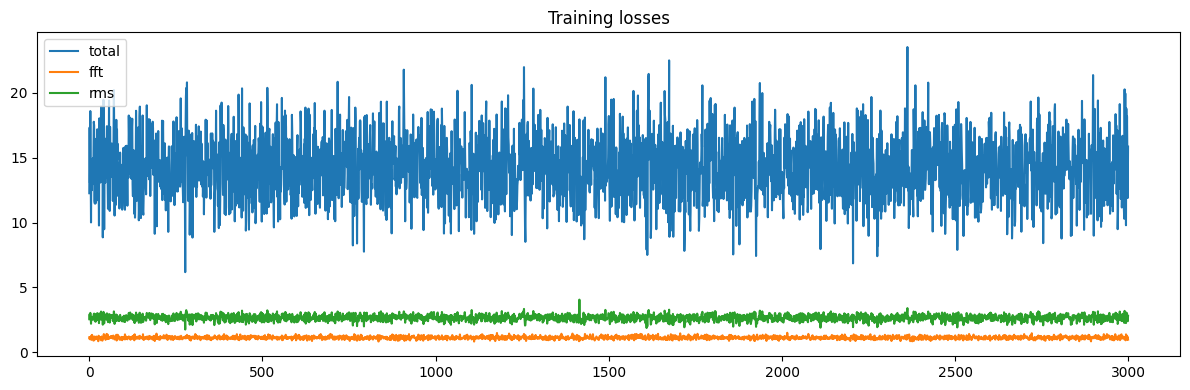

In [11]:
# CELL 9 — Loss curves
plt.figure(figsize=(12,4))
plt.plot(history["loss"], label="total")
plt.plot(history["fft"], label="fft")
plt.plot(history["rms"], label="rms")
plt.legend()
plt.title("Training losses")
plt.tight_layout()
plt.show()


In [12]:
# CELL 10 — Augmentation (CORRECT: normalize-space residual only)

def rms_np(x):
    return float(np.sqrt(np.mean(x**2) + 1e-12))

def augment_one(real_signal):
    real_signal = real_signal.astype(np.float32)
    x = tf.convert_to_tensor(real_signal[None, :, None])   # (1,T,1)

    # sadece RMS hedefi için başka bir excavation örneği
    row2 = exc_df.sample(1).iloc[0]
    x2 = _load_signal_from_row(row2, WINDOW_SIZE).astype(np.float32)

    # normalize uzayda residual
    r_real = (x2 - real_signal).astype(np.float32)
    r_real_std = float(np.std(r_real) + 1e-6)   # normalize uzayda gerçek residual ölçeği
    k = 0.3  # augmentation şiddeti (0.1–0.5 arası)
    target = k * r_real_std

    # normalize residual (sample-wise)
    r_real_tf = tf.convert_to_tensor(r_real[None, :, None])
    r_real_n, _, _ = normalize_residual(r_real_tf)
    r_real_n = r_real_n[0, :, 0].numpy()

    # GAN normalize residual üretir
    z = tf.random.normal((1, WINDOW_SIZE, LATENT_CH))
    r_gan_n = GEN([x, z], training=False)[0, :, 0].numpy()

    # 🔴 DC OFFSET TEMİZLE (kritik)
    r_gan_n = r_gan_n - np.mean(r_gan_n)

    # RMS eşitleme (normalize uzayda)
    target = rms_np(r_real_n)
    g_std = float(np.std(r_gan_n) + 1e-6)
    alpha = target / g_std
    alpha = np.clip(alpha, 0.05, 0.6)  # güvenlik
    r_scaled = alpha * r_gan_n
    fake = real_signal + r_scaled

    return fake.astype(np.float32), r_scaled.astype(np.float32), r_real_n.astype(np.float32), alpha

# örnek üret
sample_row = exc_df.sample(1, random_state=RNG_SEED).iloc[0]
real = _load_signal_from_row(sample_row, WINDOW_SIZE).astype(np.float32)
fake, r_gan, r_real, alpha = augment_one(real)

print("alpha:", alpha)
print("RMS real residual (example):", rms_np(r_real))
print("RMS GAN residual  (scaled):", rms_np(r_gan))
print("real min/max:", real.min(), real.max(), "mean/std:", real.mean(), real.std())
print("fake min/max:", fake.min(), fake.max(), "mean/std:", fake.mean(), fake.std())
print("r_gan min/max:", r_gan.min(), r_gan.max(), "mean/std:", r_gan.mean(), r_gan.std())


alpha: 0.6
RMS real residual (example): 0.9999999105935289
RMS GAN residual  (scaled): 0.06930202340470269
real min/max: 0.005493164 1.0291748 mean/std: 0.31677482 0.13753851
fake min/max: -0.24187595 1.0823036 mean/std: 0.3167748 0.15467909
r_gan min/max: -0.2815899 0.2790945 mean/std: -4.810095e-09 0.06930202


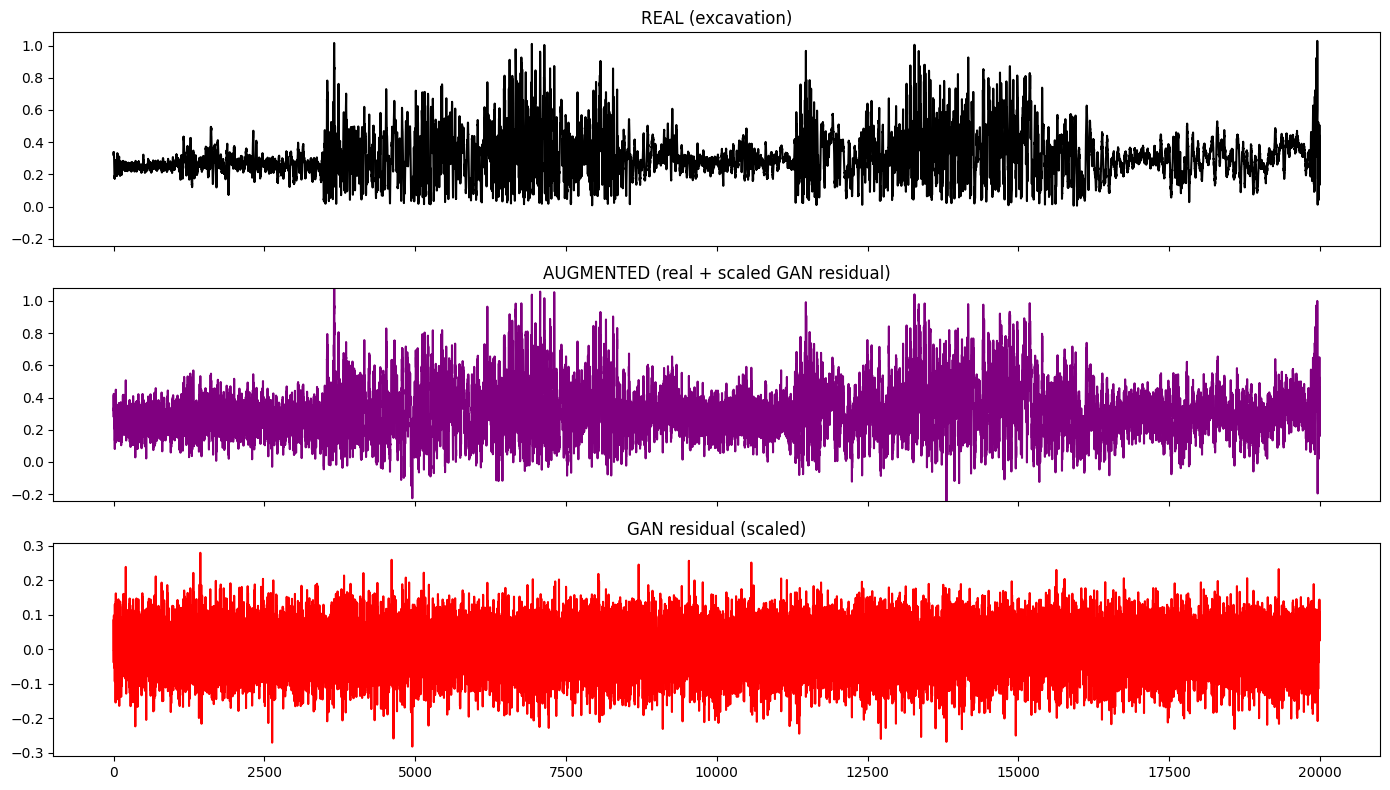

In [13]:
# CELL 11 — Waveform plot (real vs augmented) + residuals
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

ylim = (min(real.min(), fake.min()), max(real.max(), fake.max()))

ax1.plot(real, color="black")
ax1.set_title("REAL (excavation)")
ax1.set_ylim(ylim)

ax2.plot(fake, color="purple")
ax2.set_title("AUGMENTED (real + scaled GAN residual)")
ax2.set_ylim(ylim)

ax3.plot(r_gan, color="red")
ax3.set_title("GAN residual (scaled)")

plt.tight_layout()
plt.show()


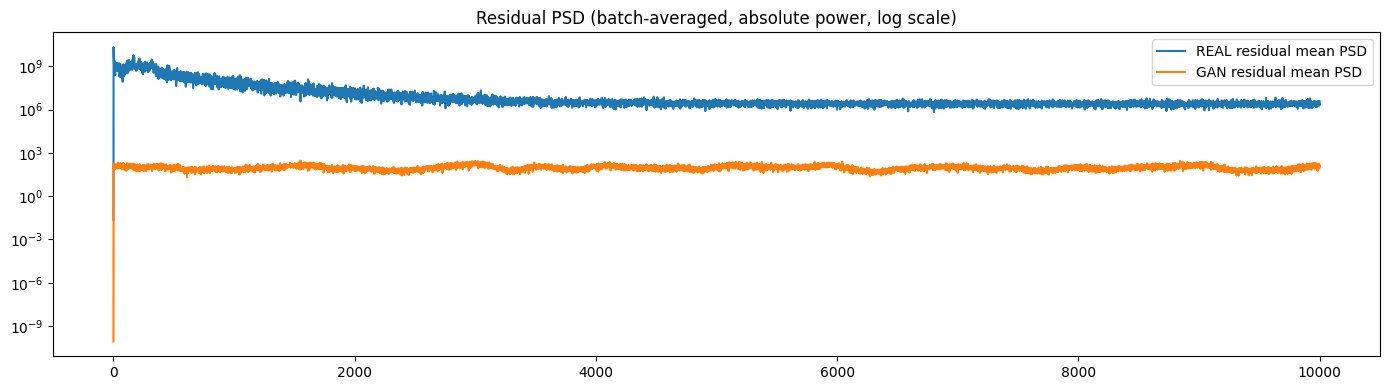

In [14]:
# CELL 12 — Batch-averaged PSD comparison (real residual vs GAN residual)
def mean_psd(residuals):
    Ps = []
    for r in residuals:
        x = r - np.mean(r)
        X = np.fft.rfft(x)
        Ps.append(np.abs(X)**2)
    return np.mean(Ps, axis=0)

# collect
N = 16
real_residuals = []
gan_residuals = []

# choose a fixed anchor real signal for fair comparison
anchor_row = exc_df.sample(1, random_state=RNG_SEED).iloc[0]
anchor = _load_signal_from_row(anchor_row, WINDOW_SIZE).astype(np.float32)

for _ in range(N):
    # real residual
    row2 = exc_df.sample(1).iloc[0]
    x2 = _load_signal_from_row(row2, WINDOW_SIZE).astype(np.float32)
    real_residuals.append(x2 - anchor)

    # gan residual (scaled)
    _, r_g, _, _ = augment_one(anchor)
    gan_residuals.append(r_g)

P_real = mean_psd(real_residuals)
P_gan  = mean_psd(gan_residuals)

plt.figure(figsize=(14,4))
plt.semilogy(P_real + 1e-12, label="REAL residual mean PSD")
plt.semilogy(P_gan  + 1e-12, label="GAN residual mean PSD")
plt.legend()
plt.title("Residual PSD (batch-averaged, absolute power, log scale)")
plt.tight_layout()
plt.show()


In [15]:
# CELL 13 — Save / Load weights (offline, checkpoints)
WEIGHTS_DIR = DATA_FOLDER / "gan_weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

weights_path = WEIGHTS_DIR / f"residual_gan_{LABEL}_norm.keras"
GEN.save_weights(weights_path)
print("Saved:", weights_path)



Saved: /tf/start_training/data/signal/2025-11-27_5clf_best_data/gan_weights/residual_gan_excavation_norm.keras


In [16]:
# ===============================
# Residual GAN fine-tuning loop
# ===============================

# ---- güvenli ayarlar ----
N_STEPS = 300            # 200–300 yeterli
PRINT_EVERY = 50
LR = 1e-5

# ---- model trainable açık mı? ----
for layer in GEN.layers:
    layer.trainable = True
GEN.trainable = True

print("Trainable weights:", len(GEN.trainable_weights))

# ---- optimizer YENİDEN ----
opt = tf.keras.optimizers.Adam(
    learning_rate=LR,
    beta_1=0.5,
    beta_2=0.9
)

# ---- loss logları ----
loss_hist = []
fft_hist  = []
rms_hist  = []
alpha_hist = []

# ---- sabit bir real örnek (sanity check için) ----
real_row = exc_df.sample(1, random_state=RNG_SEED).iloc[0]
real_ref = _load_signal_from_row(real_row, WINDOW_SIZE).astype(np.float32)
def fft_mag_loss(r_gan, r_real):
    """
    Log-magnitude FFT loss for residual matching.
    r_gan, r_real: (1, T, 1)
    """
    r_gan = tf.squeeze(r_gan, axis=-1)   # (1, T)
    r_real = tf.squeeze(r_real, axis=-1) # (1, T)

    # FFT
    Fg = tf.signal.rfft(r_gan)
    Fr = tf.signal.rfft(r_real)

    # log magnitude
    Mg = tf.math.log1p(tf.abs(Fg))
    Mr = tf.math.log1p(tf.abs(Fr))

    return tf.reduce_mean(tf.abs(Mg - Mr))

# ===============================
# TRAIN LOOP
# ===============================
for step in range(N_STEPS):

    # --- batch seç ---
    row1 = exc_df.sample(1).iloc[0]
    row2 = exc_df.sample(1).iloc[0]

    x1 = _load_signal_from_row(row1, WINDOW_SIZE).astype(np.float32)
    x2 = _load_signal_from_row(row2, WINDOW_SIZE).astype(np.float32)

    r_real = (x2 - x1).astype(np.float32)

    x1_tf = tf.convert_to_tensor(x1[None, :, None])
    r_real_tf = tf.convert_to_tensor(r_real[None, :, None])

    # normalize residual
    r_real_n, r_mean, r_std = normalize_residual(r_real_tf)

    z = tf.random.normal((1, WINDOW_SIZE, LATENT_CH))

    with tf.GradientTape() as tape:
        r_gan_n = GEN([x1_tf, z], training=True)
        r_gan = denormalize_residual(r_gan_n, r_mean, r_std)

        # --- losses ---
        loss_fft = fft_mag_loss(r_gan, r_real_tf)
        loss_rms = tf.abs(
            tf.sqrt(tf.reduce_mean(r_gan**2)) -
            tf.sqrt(tf.reduce_mean(r_real_tf**2))
        )

        loss = loss_fft + loss_rms

    grads = tape.gradient(loss, GEN.trainable_weights)
    opt.apply_gradients(zip(grads, GEN.trainable_weights))

    # ---- logging ----
    loss_hist.append(float(loss))
    fft_hist.append(float(loss_fft))
    rms_hist.append(float(loss_rms))

    # ---- sanity check ----
    if step % PRINT_EVERY == 0:
        fake, r_gan_ex, r_real_ex, alpha = augment_one(real_ref)

        alpha_hist.append(alpha)

        print(
            f"[{step}] "
            f"loss={loss:.4f} "
            f"fft={loss_fft:.4f} "
            f"rms={loss_rms:.4f} | "
            f"RMS(n) gan={rms_np(r_gan_ex):.3f} real=1.000 | "
            f"alpha={alpha:.3f}"
        )

        # kırmızı bayrak
        if rms_np(r_gan_ex) > 1.5 or alpha > 1.5:
            print("⚠️  STOP: residual out of control")
            break
GEN.save_weights("residual_wavegan_excavation_finetuned_v2.keras")

Trainable weights: 10


2025-12-16 08:46:10.111054: I external/local_xla/xla/service/service.cc:168] XLA service 0x40cebf10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-16 08:46:10.111079: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-12-16 08:46:10.125040: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1765874770.238928  964166 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[0] loss=1772.4998 fft=1.4270 rms=1771.0728 | RMS(n) gan=0.068 real=1.000 | alpha=0.600
[50] loss=79.3524 fft=1.6067 rms=77.7456 | RMS(n) gan=0.067 real=1.000 | alpha=0.600
[100] loss=4.1008 fft=2.0500 rms=2.0508 | RMS(n) gan=0.067 real=1.000 | alpha=0.600
[150] loss=29.5511 fft=1.3606 rms=28.1904 | RMS(n) gan=0.067 real=1.000 | alpha=0.600
[200] loss=89.4266 fft=0.7071 rms=88.7195 | RMS(n) gan=0.065 real=1.000 | alpha=0.600
[250] loss=1.0215 fft=0.8124 rms=0.2091 | RMS(n) gan=0.065 real=1.000 | alpha=0.600


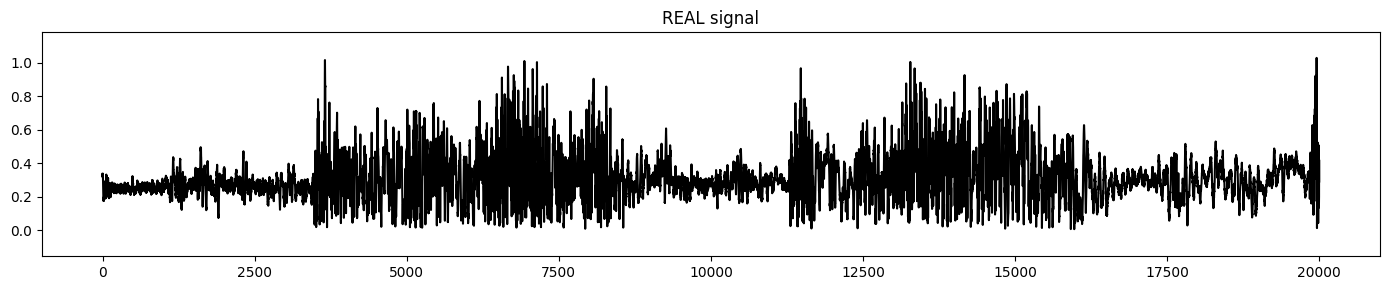

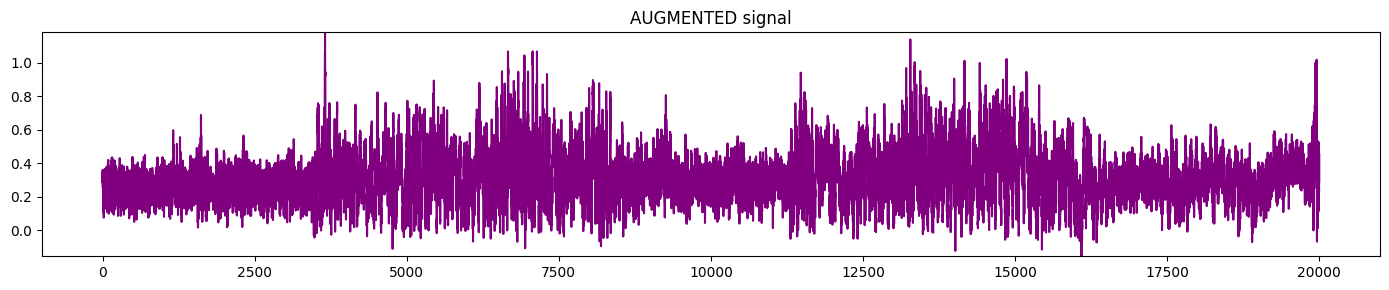

<Figure size 1400x300 with 0 Axes>

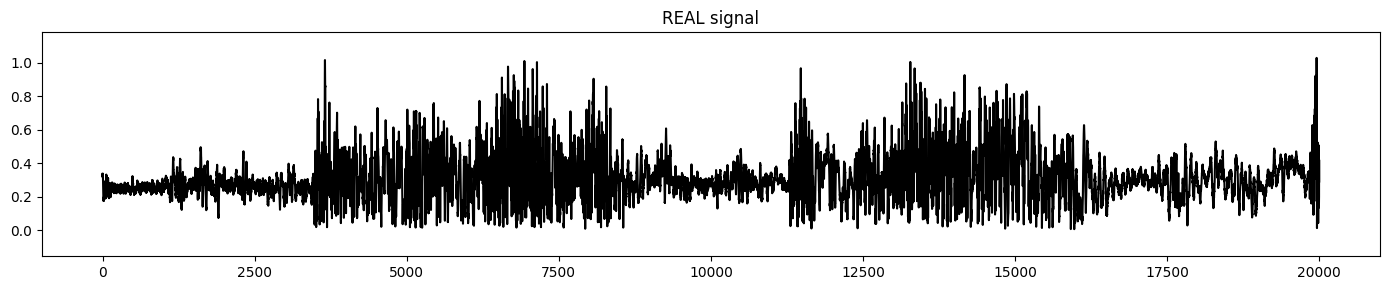

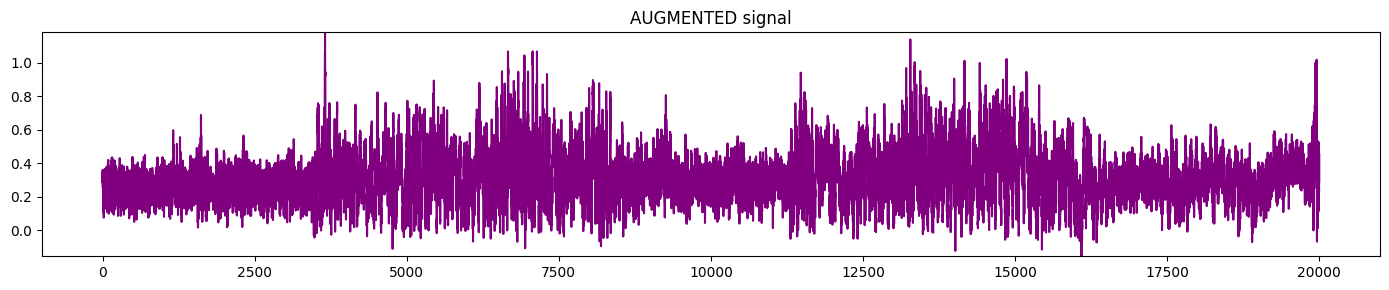

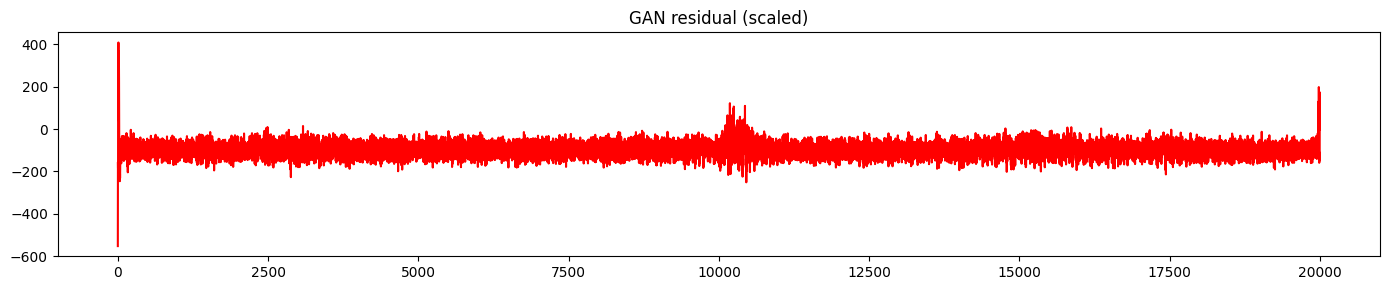

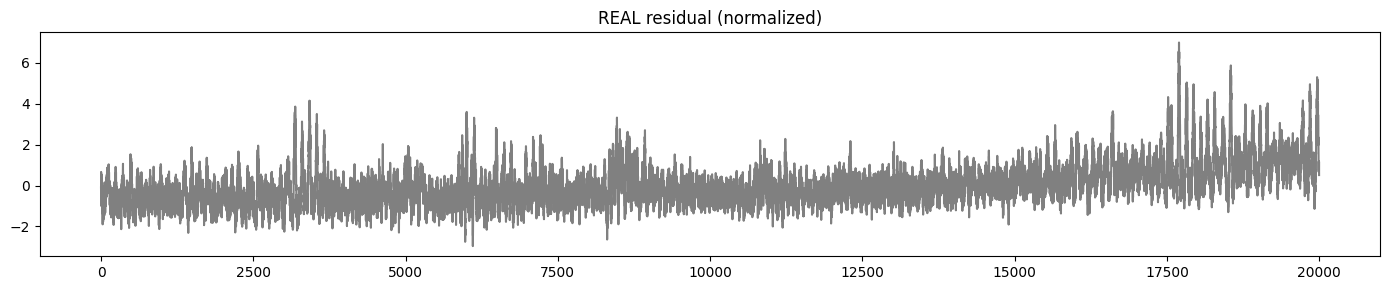

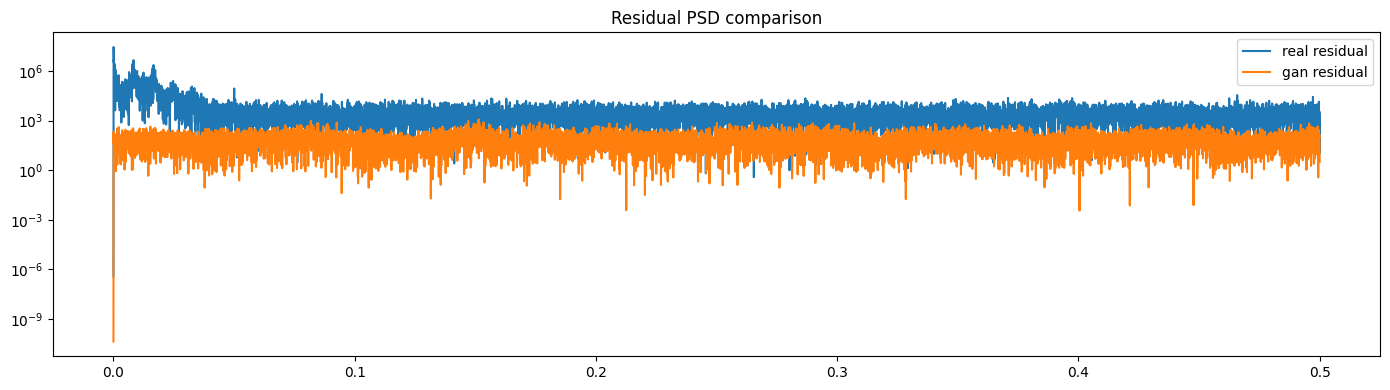

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_psd(x, label, fs=1.0):
    X = np.fft.rfft(x)
    psd = np.abs(X)**2
    freqs = np.fft.rfftfreq(len(x), d=1/fs)
    plt.semilogy(freqs, psd + 1e-12, label=label)

# ---- ortak y-lim (real vs fake) ----
ylim_rf = (
    min(real.min(), fake.min()),
    max(real.max(), fake.max())
)

# =========================
# 1️⃣ REAL
# =========================
plt.figure(figsize=(14,3))
plt.plot(real, color="black")
plt.title("REAL signal")
plt.ylim(ylim_rf)
plt.tight_layout()
plt.show()

# =========================
# 2️⃣ AUGMENTED (REAL + GAN residual)
# =========================
plt.figure(figsize=(14,3))
plt.plot(fake, color="purple")
plt.title("AUGMENTED signal")
plt.ylim(ylim_rf)
plt.tight_layout()
plt.show()

# =========================
# 3️⃣ GAN RESIDUAL (scaled)
# =========================
plt.figure(figsize=(14,3))
import matplotlib.pyplot as plt

def plot_psd(x, label, fs=1.0):
    X = np.fft.rfft(x)
    psd = np.abs(X)**2
    freqs = np.fft.rfftfreq(len(x), d=1/fs)
    plt.semilogy(freqs, psd + 1e-12, label=label)

# ---- ortak y-lim (real vs fake) ----
ylim_rf = (
    min(real.min(), fake.min()),
    max(real.max(), fake.max())
)

# =========================
# 1️⃣ REAL
# =========================
plt.figure(figsize=(14,3))
plt.plot(real, color="black")
plt.title("REAL signal")
plt.ylim(ylim_rf)
plt.tight_layout()
plt.show()

# =========================
# 2️⃣ AUGMENTED (REAL + GAN residual)
# =========================
plt.figure(figsize=(14,3))
plt.plot(fake, color="purple")
plt.title("AUGMENTED signal")
plt.ylim(ylim_rf)
plt.tight_layout()
plt.show()

# =========================
# 3️⃣ GAN RESIDUAL (scaled)
# =========================
plt.figure(figsize=(14,3))
# handle TF tensor or numpy array, and squeeze to 1D
r_gan_arr = r_gan.numpy() if hasattr(r_gan, "numpy") else np.asarray(r_gan)
plt.plot(np.squeeze(r_gan_arr), color="red")
plt.title("GAN residual (scaled)")
plt.tight_layout()
plt.show()

# =========================
# 4️⃣ REAL RESIDUAL (normalized)
# =========================
plt.figure(figsize=(14,3))
# use the normalized 1D residual arrays (r_real_ex and r_gan_ex) to avoid indexing errors
plt.plot(r_real_ex, color="gray")
plt.title("REAL residual (normalized)")
plt.tight_layout()
plt.show()

# =========================
# 5️⃣ PSD: residual comparison
# =========================
plt.figure(figsize=(14,4))
# compare PSDs using the 1D numpy arrays
plot_psd(r_real_ex, "real residual")
plot_psd(r_gan_ex,  "gan residual")
plt.legend()
plt.title("Residual PSD comparison")
plt.tight_layout()
plt.show()


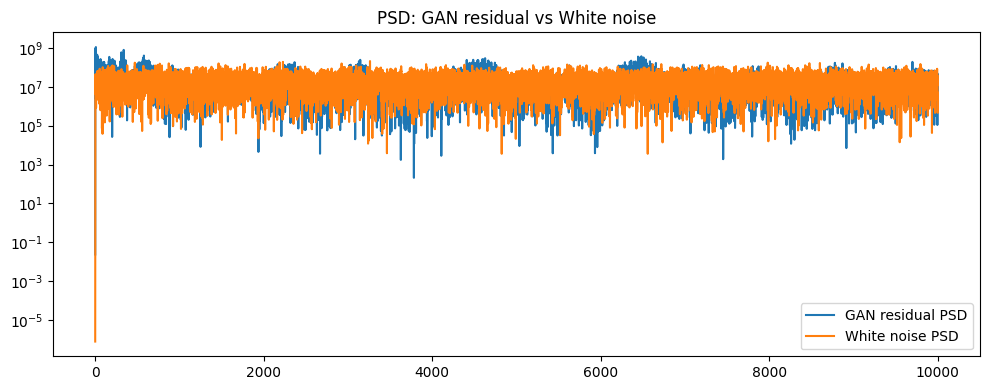

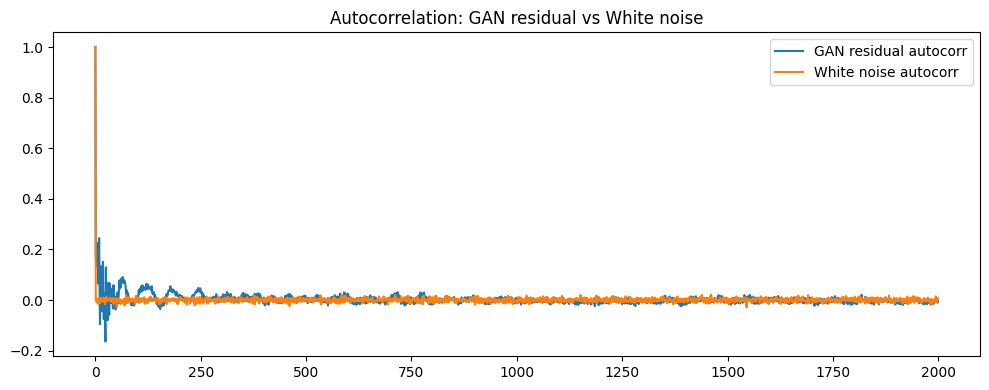

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def autocorr(x, max_lag=2000):
    x = x - np.mean(x)
    ac = np.correlate(x, x, mode="full")
    ac = ac[len(ac)//2:len(ac)//2 + max_lag]
    return ac / (ac[0] + 1e-12)

def psd(x):
    X = np.fft.rfft(x - np.mean(x))
    return np.abs(X)**2

# GAN residual: r_gan (scaled)
g = np.squeeze(r_gan.numpy())   # (T,)

# White noise same std
w = np.random.normal(0, np.std(g), size=g.shape).astype(np.float32)

# PSD
Pg, Pw = psd(g), psd(w)

plt.figure(figsize=(10,4))
plt.semilogy(Pg + 1e-12, label="GAN residual PSD")
plt.semilogy(Pw + 1e-12, label="White noise PSD")
plt.legend(); plt.title("PSD: GAN residual vs White noise"); plt.tight_layout(); plt.show()

# Autocorr
Ag, Aw = autocorr(g), autocorr(w)

plt.figure(figsize=(10,4))
plt.plot(Ag, label="GAN residual autocorr")
plt.plot(Aw, label="White noise autocorr")
plt.legend(); plt.title("Autocorrelation: GAN residual vs White noise"); plt.tight_layout(); plt.show()
